In [ ]:
最適なペア順に信号線値を並べ替えたファイル（s~simular_output）をもとに、最適なペアの信号線を統合し、正解データを作成
※s~simular_outputファイルは、s~outputファイルの行と列が入れ替わっていることに注意⇒詳しくはokinaka.txtを参照

In [ ]:
import numpy as np

cir = 's15850'  # 対象回路
simular_output = cir + 'simular_output'  # 最適なペア順に並べ替えられた正解データファイル
net_list = 'c' + cir   # ネットリストファイル
integrated_output = cir + 'integrated_output'  # 統合後の正解データファイル

integration = 2 # 故障候補値の統合数

# 正解データファイルを開いてデータを読み込む
with open(simular_output) as f:
  single_flag = int(f.readline().split()[0])  # 最適なペアが存在しない信号線があるかどうかを示す # 0:存在しない, 1:存在する
  # print("余りがあるかどうか:", remainder_flag)

  # 2行目（最適なペア信号線）を読み込む。カンマ区切りで各信号線をリストに格納
  best_pair = f.readline().split(',')

  #3行目意向を読み込む。_にいれた各文字列の空白文字を削除
  correct_data = [_.replace(",", "").replace("\n", "") for _ in f.readlines()]  # 各行の空白文字と改行文字を削除

print(correct_data[0])  # 正解データの1行目を表示
print(len(correct_data))  # 正解データの行数を表示

# 統合する信号線の数＝対象の信号線からペアが存在しない信号線を除いた数
integrated_target_line_sum = len(correct_data)  - single_flag

# 信号線統合後の正解データを格納するリスト
integrated_data = [["0" for _ in range(len(correct_data[0]))] for _ in range(integrated_target_line_sum // integration + single_flag)] # 2次元配列を0で初期化。列数は故障候補値の数（correct_dataの列数）、行数は信号線数をintegrationで割った商にflagを足したもの＝統合後の信号線数。flagは、最適なペアが存在しない信号線があるとき1、ないとき0
print("inte", integrated_target_line_sum // integration + single_flag)
# print(len(integrated_data))
# print(len(integrated_data[0]))

# 信号線を統合したときの正解データを作成
integrated_index = 0  # 統合した信号線のインデックス
for i in range(0, integrated_target_line_sum, integration):  # 故障候補値をintegration個ずつ統合
  for j in range(len(correct_data[i])):
    if correct_data[i][j] == '0' and correct_data[i+1][j] == '0':  # どちらの信号線も0のとき
      integrated_data[integrated_index][j] = '0'
    elif correct_data[i][j] == '1' and correct_data[i+1][j] == '0':  # 信号線番号が小さい方の信号線が1のとき
      integrated_data[integrated_index][j] = '1'
    elif correct_data[i][j] == '0' and correct_data[i+1][j] == '1':  # 信号線番号が大きい方の信号線が1のとき
      integrated_data[integrated_index][j] = '2'
    elif correct_data[i][j] == '1' and correct_data[i+1][j] == '1':  # どちらの信号線も1のとき
      integrated_data[integrated_index][j] = '3'
  
  integrated_index += 1

# print(integrated_index)

# 最適なペアが存在しない信号線があるとき
if single_flag == 1:
  integrated_data[integrated_index] = correct_data[i+2]
  print(integrated_data[integrated_index])
  print("最適なペアが存在しない信号線があります。")

# 統合した正解データを転置　⇒　intewgrated_dataの行と列を入れ替える ⇒　各信号線の故障候補値を列ごとに書き込むため
integrated_data2 = [list(col) for col in zip(*integrated_data)]

# 統合した正解データをファイルに書き込む
with open(integrated_output, 'w') as f:
  # 最適なペアが存在しない信号線があるかどうかを示す, 0:存在しない, 1:存在する
  if single_flag == 0: # ペアが存在しない信号線がない場合＝統合に余りがない場合
    f.write(f"0 #ペアが存在しない信号線はありません(最後の列の値も統合されています）\n")  # 信号線数を出力
  else:  # ペアが存在しない信号線があります＝統合に余りがある場合
    f.write(f"1 #ペアが存在しない信号線はあります（最後の列の値は統合されていません）\n") 

  # 統合後の信号線数を書き込む
  f.write(str(len(integrated_data2[0])) + '\n')

  # 最適なペア信号線を書き込む
  for i in range(len(best_pair) - 1):
    f.write(best_pair[i] + ',')  # 2行目に最適なペア信号線を書き込む
  f.write(best_pair[i+1])

  # 3行目以降に統合した正解データを書き込む
  for data in integrated_data2:
    f.write(','.join(data) + '\n')

  print("終了しました")



1000000000000101000000100101000010001010100000000100000010101000010100000100000010000100000010001000011001010101000000000101000000100100000000100101000000000101000010000101000000100100000000000101000000000101000000000101000010000100000000000100000010101010101100000100000010101010110000010101000010001000111000000101000000101010000101000100000010101000001100000101000010101010110000000101000010101010011001000100000000001000101000001000011000001010011101011000101100001000010100001000000000001000100001001000010001001010100000000100000010000100000000000101000010000101000010001000111001001010001101001000010101000100000000001000010000000101000010001010000000011010110101001000100001001000110000001000101001000100000010000101000010000100000010000101000000001000100001001000010100000100000010101010000100011010011001011010010000001000000101001000101100011010001001011010011001011010100101000100000000100100000010001010110100000101000000001010100100001000000100001000011101001010111100001010100001011000

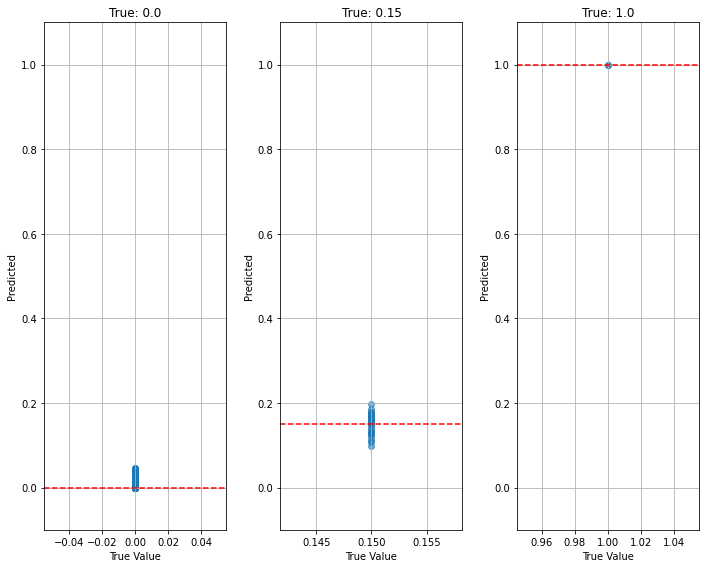

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# あなたの正解データを1次元に展開 (例)
y_true = np.array([
    0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.15,0.15,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,
    0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.15,1.0,
    0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.15,
    0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,
    0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,
    0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
    0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.15,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,
    0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
    0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.15,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,
    0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.15,0.0
])

# 仮のモデル出力（ここでは正解値にノイズを加えたダミーデータを作成）
np.random.seed(0)
y_pred = y_true + np.random.normal(0, 0.02, size=y_true.shape)
y_pred = np.clip(y_pred, 0, 1) 

# 正解値ごとに分けて描画
labels = np.unique(y_true) #

plt.figure(figsize=(10, 8))

for i, label in enumerate(labels):
    mask = y_true == label
    y_pred_label = y_pred[mask]

    plt.subplot(1, len(labels), i+1) # 
    plt.scatter([label]*len(y_pred_label), y_pred_label, alpha=0.6)
    plt.axhline(label, color='r', linestyle='--')
    plt.ylim(-0.1, 1.1)
    plt.title(f'True: {label}')
    plt.xlabel('True Value')
    plt.ylabel('Predicted')
    plt.grid(True)

plt.tight_layout()
plt.show()


2025-11-07 23:03:47.055861: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-07 23:03:47.077215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762524227.099127 2867155 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762524227.105579 2867155 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762524227.122590 2867155 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

output_node_num: 24
labels: [0.   0.25 0.75 1.  ]


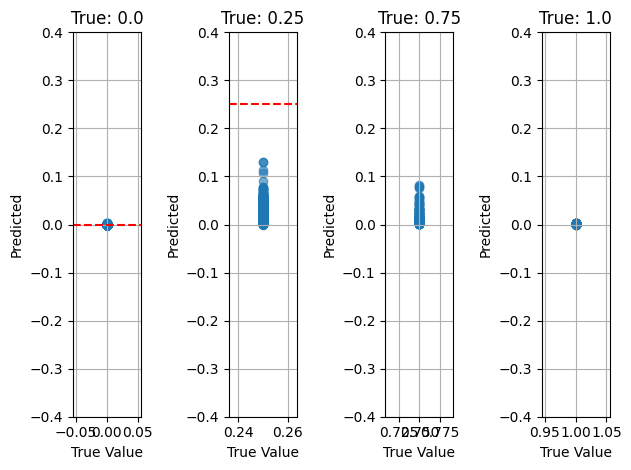

output_node_num: 24
labels: [0.   0.25 0.75 1.  ]


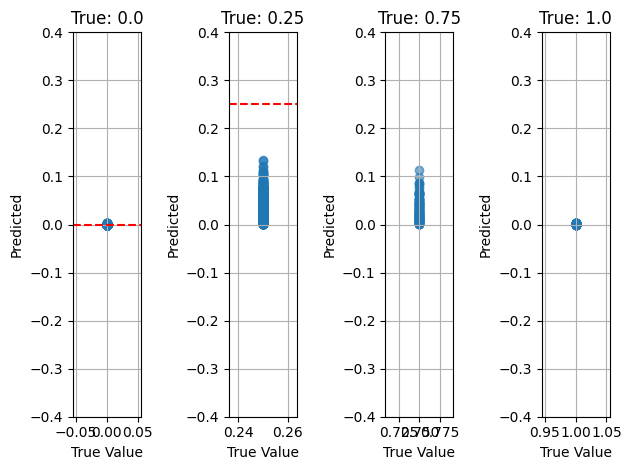

output_node_num: 24
labels: [0.   0.25 0.75 1.  ]


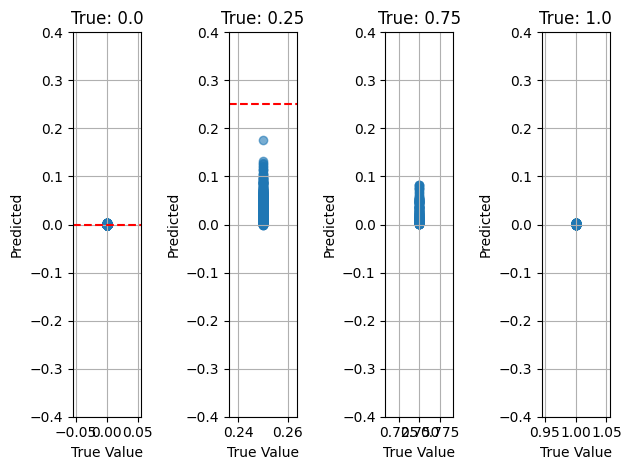

output_node_num: 24
labels: [0.   0.25 0.75 1.  ]


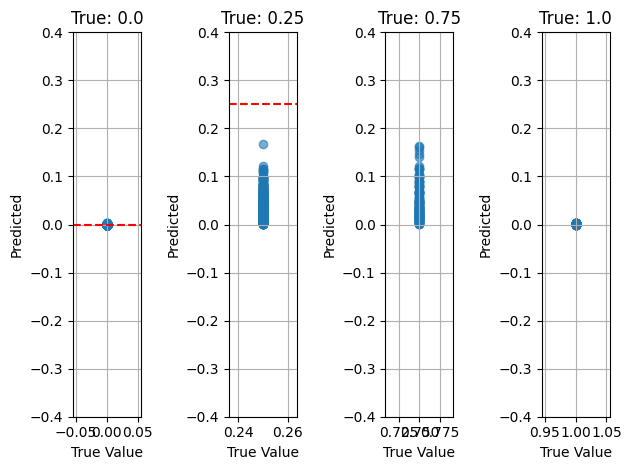

output_node_num: 24
labels: [0.   0.25 0.75 1.  ]


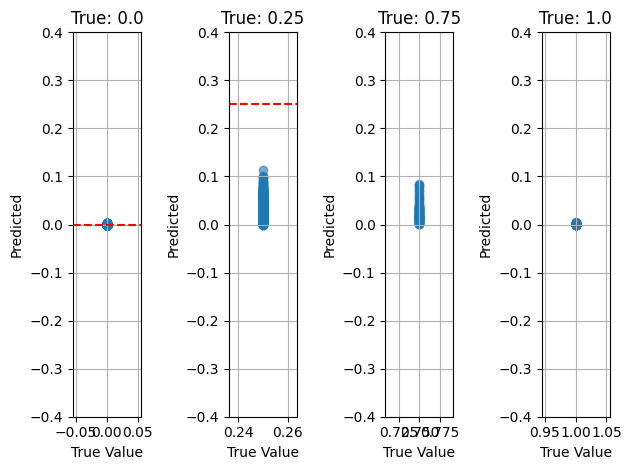

output_node_num: 24
labels: [0.   0.25 0.75 1.  ]


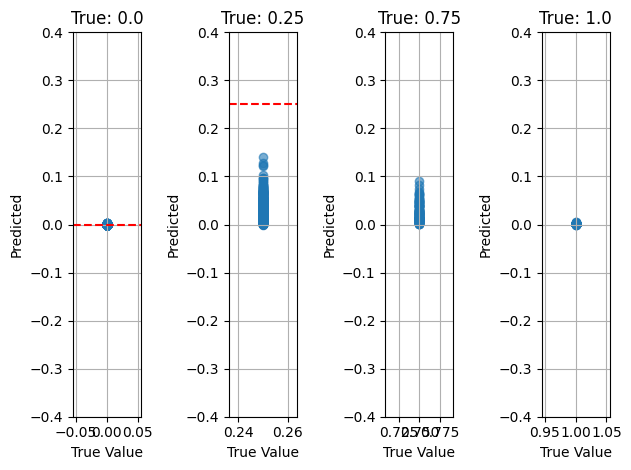

output_node_num: 24
labels: [0.   0.25 0.75 1.  ]


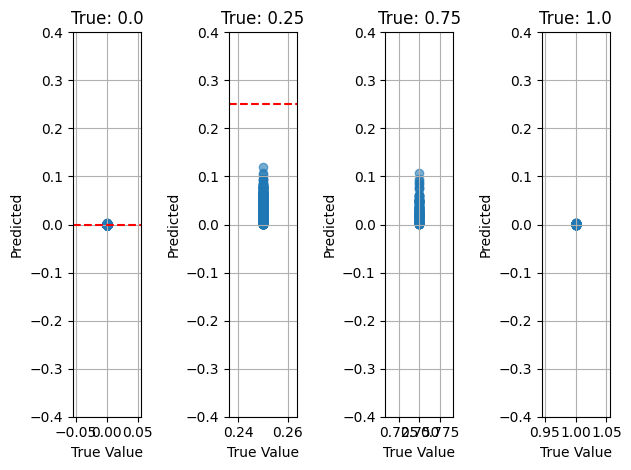

In [2]:
# 学習済みのANNが出力した値と正解データの値を比較して、距離を計算するプログラム
# cd workspace/research2/experiment
#　実行コマンド：　python3 diagnosis.py

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


#グローバル変数
cir = 's344'  # 対象回路
input_data_file = cir + 'input'  # 入力データファイル
correct_data_file = cir + '分割正解データ' + '/' + cir + 'integrated_output'  # 統合後の正解データファイル
suplit_num_file = cir + '分割正解データ' + '/' + cir + 'suplit_num'  # モデルの分割数が保存されたファイル
suplit_data_num_file = cir + '分割正解データ' + '/' + cir + 'suplit_data_num'  # データの分割数が保存されたファイル
single_line_file = cir + '分割正解データ' + '/' + cir + 'single_line'  # 統合されていない信号線があるかが保存されたファイル
input_data_num = None  # 1個のモデルにおける学習データ数
input_node_num = None  #入力層におけるノード数 初期値は8　学習結果によって変更
output_node_num = None #　出力層のノード数＝分割数による
num_models = None  # 学習させるモデルの数
model_folder = cir + 'sepmodel'  # 学習済みモデルを保存するフォルダ
fault_line_num = None  # 故障診断対象の回路における故障信号線の総数
error_file = 'data_error/' + cir + 'model_error/'  # 出力データと正解データの距離を保存するファイル


def mk_input_data():
    # 入力データファイルを開いてデータを読み込む
    with open(input_data_file) as f:
        lines = [_.replace(",", "").replace("\n", "") for _ in f.readlines()]

    # print(lines)
    
    global input_data_num
    input_data_num = int(len(lines))      #学習データ数を設定。学習データ数は入力データの行数
    global input_node_num               #グローバル変数を書き換え
    input_node_num = int(len(lines[0]))      #入力ノード数を設定。入力ノード数は入力データの各行の要素数

    int_lines = [list(map(int, _)) for _ in lines]  #list要素の型をint型に変換

    return np.array(int_lines)


def mk_output_data(fname):

    # 正解データファイルを開いてデータを読み込む
    with open(fname) as f:
        correct_output_data = [_.replace("\n", "") for _ in f.readlines()]

    correct_output_data = [value.split(",") for value in correct_output_data] # カンマ区切りで各信号線をリストに格納

    # print("dsadsa")
    # print(lines[0])

    for i in range(len(correct_output_data)):
        for j in range(len(correct_output_data[i])):
            correct_output_data[i][j] = float(correct_output_data[i][j])

    # print("gaga")
    # print(lines[0])
    
    global output_node_num               #グローバル変数を書き換え
    output_node_num = int(len(correct_output_data[0]))      #出力ノード数を設定。出力ノード数は正解データの各行の要素数
    print("output_node_num:", output_node_num)

    return correct_output_data



if __name__ == '__main__':  
    
  # 学習済みの機械学習モデルに入力データを与えて、出力を取得する
    # 入力データをファイルから読み込む
    input_data = mk_input_data()

    # 分割モデルの数を取得
    with open(suplit_num_file, 'r') as f:
        num_models = int(f.readline())
  
    # データを何個づつ分割したのかを取得
    with open(suplit_data_num_file, 'r') as f:
        suplit_data_num = int(f.readline().replace("\n", ""))  # データの分割数を取得
        # print(suplit_data_num)


    # 統合されていない信号線があるかどうかを取得 0: 統合されてない信号線がない、1: 統合されていない信号線がある
    # 統合されていない信号線がある場合、最後のモデルの最後の出力ノードの値は統合されていない
    with open(single_line_file, 'r') as f:
        single_flag = int(f.readline().replace("\n", ""))

    for model_id in range(num_models):

        # モデルの読み込み
        with open(model_folder + '/' + cir + 'model_' + str(model_id) + '.tflite', 'rb') as f:  # モデルを読み込むファイルを開く
            tflite_model = f.read()

        # モデルの評価
        interpreter = tf.lite.Interpreter(model_content=tflite_model)  # TFLite形式のモデルを読み込む。保存されたTFLiteモデルをメモリに読み込み、推論を行う準備をするためのインタープリターを作成します。
        interpreter.allocate_tensors()  # #メモリを確保。モデルが使用するテンソル（データ構造）をメモリに割り当てます。TFLiteモデルをインタープリターにロードするだけでは、テンソルのメモリは割り当てられていません。この行を実行することで、モデルが推論に必要なメモリを確保します。

        input_details = interpreter.get_input_details()  # モデルの入力テンソルの詳細を取得。モデルの入力に関する詳細情報をリスト形式で返します。各要素は、入力テンソルの形状、データ型、名前などの情報を含む辞書です。
        output_details = interpreter.get_output_details()  # モデルの出力テンソルの詳細を取得。モデルの出力に関する詳細情報をリスト形式で返します。各要素は、出力テンソルの形状、データ型、名前などの情報を含む辞書です。

        correct_file = correct_data_file + str(model_id)  # 分割された正解データファイル名に変更　＝　s344分割正解データ/s344integrated_output + 番号
        correct_output_data = mk_output_data(correct_file)  # 関数内でグローバル変数output_node_numを設定
        correct_output_data = np.array(correct_output_data).flatten() # correct_output_dataは二次元配列なので一次元配列に変換        

        output_data = [[0 for _ in range(output_node_num)] for _ in range(input_data_num)]  # 出力データを格納するリスト output_data[テストパターン数][出力ノード数]。output_data[4][2]には、テストパターン4に対するモデルの出力値が格納される

        for i in range(input_data_num):
            
            input_shape = input_details[0]['shape']  # 入力データの形状を取得.先ほど取得したinput_detailsのリストの中から、形状情報を取得。input_details[0]['shape']は、入力テンソルの形状を取得するためのコードです。['shape']は、辞書内の shape キーを指定しています。

            reshape_input_data = np.reshape(input_data[i], input_shape)  # NumPy配列の形状を指定した形 (input_shape) に変更します。これにより、入力データの形状がモデルの入力テンソルの形状と一致します。


            # モデルの入力データを設定
            interpreter.set_tensor(input_details[0]['index'], np.array(reshape_input_data, dtype=np.float32))   # モデルの入力テンソルにデータを設定します。入力テンソルのインデックス、データを指定します。[0]['index']は、入力テンソルのインデックスを取得するためのコードです。

            # モデルの推論を実行
            interpreter.invoke()

            # モデルの出力データを取得
            output_data_temp = interpreter.get_tensor(output_details[0]['index'])

            output_data[i] = output_data_temp

        # output_dataは二次元配列であるため、一次元配列に変換する必要がある
        output_data = np.array(output_data).flatten()

        labels = np.unique(correct_output_data) # 正解データのリストから、重複を除いた値を取得＝4種類の正解データを取得
        print("labels:", labels)

        # 出力データの値と正解データの値を比較して、誤差を計算
        error = np.abs(output_data - correct_output_data)

        for i, label in enumerate(labels):
          mask = (correct_output_data == label) # 正解データの値がlabelと等しい要素をTrueとするマスクを作成
          error_label = error[mask]  # マスクを使って距離を抽出

          # # 距離の統計情報を表示
          # print(f"Label: {label}, Mean error: {np.mean(error_label)}, Std error: {np.std(error_label)}")

          plt.subplot(1, len(labels), i+1)
          plt.scatter([label]*len(error_label), error_label, alpha=0.6) # x座標をすべて同じ値（label）、y座標を予測値（y_pred_label）として散布図を描画
          plt.axhline(label, color='r', linestyle='--')
          plt.ylim(-0.4, 0.4)  # y軸の範囲を-0.4から0.4に設定
          plt.title(f'True: {label}')
          plt.xlabel('True Value')
          plt.ylabel('Predicted')
          plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(error_file + cir + 'error' + str(model_id) + '.png')  # PNG形式で保存
        plt.show()



